# 01 · Data Cleaning Pipeline

**Purpose:** Load the raw training dataset, perform cleaning, feature engineering, apply SMOTE oversampling, and save the final processed dataset as `combined_dataset.csv` — which is the input for `02_model_pipeline.ipynb`.

**Input:** `../data/Train Dataset.csv`  
**Output:** `../data/combined_dataset.csv`

## 1. Load Raw Dataset

In [ ]:
import pandas as pd

# Load the raw training dataset
df = pd.read_csv("../data/Train Dataset.csv")
print("Shape:", df.shape)
df.head()

## 2. Standardise Column Names

Convert all column names to lowercase with underscores for consistency.

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

Index(['unnamed:_0', 'crop', 'n', 'p', 'k', 'ph', 'rainfall', 'temperature'], dtype='object')


## 3. Drop Artefact Columns

Remove the auto-generated Pandas index column (`Unnamed: 0`) if present.

In [ ]:
if 'unnamed:_0' in df.columns:
    df = df.drop(columns=['unnamed:_0'])

## 4. Remove Duplicate Rows

In [ ]:
before = df.shape[0]
df = df.drop_duplicates()
print("Removed duplicates:", before - df.shape[0])

Removed duplicates: 10914


## 5. Resolve Feature–Label Conflicts

Remove rows where identical feature vectors map to **different** crop labels (a sign of noisy / mislabelled data).

In [ ]:
# separate features
features = df.drop(columns=['crop'])

# find duplicate feature rows
dup_mask = features.duplicated(keep=False)
dup_df = df[dup_mask]

# keep only rows where features map to ONE label
clean_df = dup_df.groupby(list(features.columns)).filter(
    lambda x: x['crop'].nunique() == 1
)

# combine with non-duplicates
non_dup_df = df[~dup_mask]
df = pd.concat([clean_df, non_dup_df]).drop_duplicates()

print("After removing conflicts:", df.shape)

After removing conflicts: (6500, 7)


## 6. Handle Missing Values

Fill any missing numeric values with column medians.

In [ ]:
print(df.isnull().sum())
for col in df.columns:
    if df[col].dtype != 'object':
        df[col] = df[col].fillna(df[col].median())

crop           0
n              0
p              0
k              0
ph             0
rainfall       0
temperature    0
dtype: int64


## 7. Validate Feature Ranges

In [ ]:
for col in df.columns:
    if df[col].dtype != 'object':
        print(col, df[col].min(), df[col].max())

n 10 180
p 10 125
k 10 200
ph 3.82 7.0
rainfall 3.274569 3322.06
temperature 1.18 35.34666667


## 8. Filter Physically Impossible Values

Remove rows with negative nutrient values and pH values outside the [0, 14] range.

In [ ]:
for col in ['n','p','k','rainfall']:
    if col in df.columns:
        df = df[df[col] >= 0]

if 'ph' in df.columns:
    df = df[(df['ph'] >= 0) & (df['ph'] <= 14)]

## 9. Clip Outliers (IQR Method)

Winsorize extreme values using the 1.5 x IQR rule to limit the influence of outliers.

In [ ]:
def clip_outliers(df, cols):
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df[col] = df[col].clip(lower, upper)
    return df

num_cols = df.select_dtypes(include='number').columns
df = clip_outliers(df, num_cols)

## 10. Class Distribution

In [ ]:
print(df['crop'].value_counts())

crop
maize          668
moong          529
rice           482
potato         461
onion          383
sunflower      362
rapeseed       361
cotton         297
ragi           293
horsegram      272
wheat          264
turmeric       259
sweetpotato    241
banana         233
soyabean       196
barley         192
coriander      190
garlic         180
jowar          103
blackpepper     71
mango           53
papaya          48
brinjal         43
tomato          43
cardamom        41
ladyfinger      32
pineapple       24
orange          23
cabbage         21
grapes          18
cauliflower     18
jackfruit       16
drumstick       14
cucumber        14
radish          11
bottlegourd     11
blackgram        9
bittergourd      9
jute             8
pumpkin          7
Name: count, dtype: int64


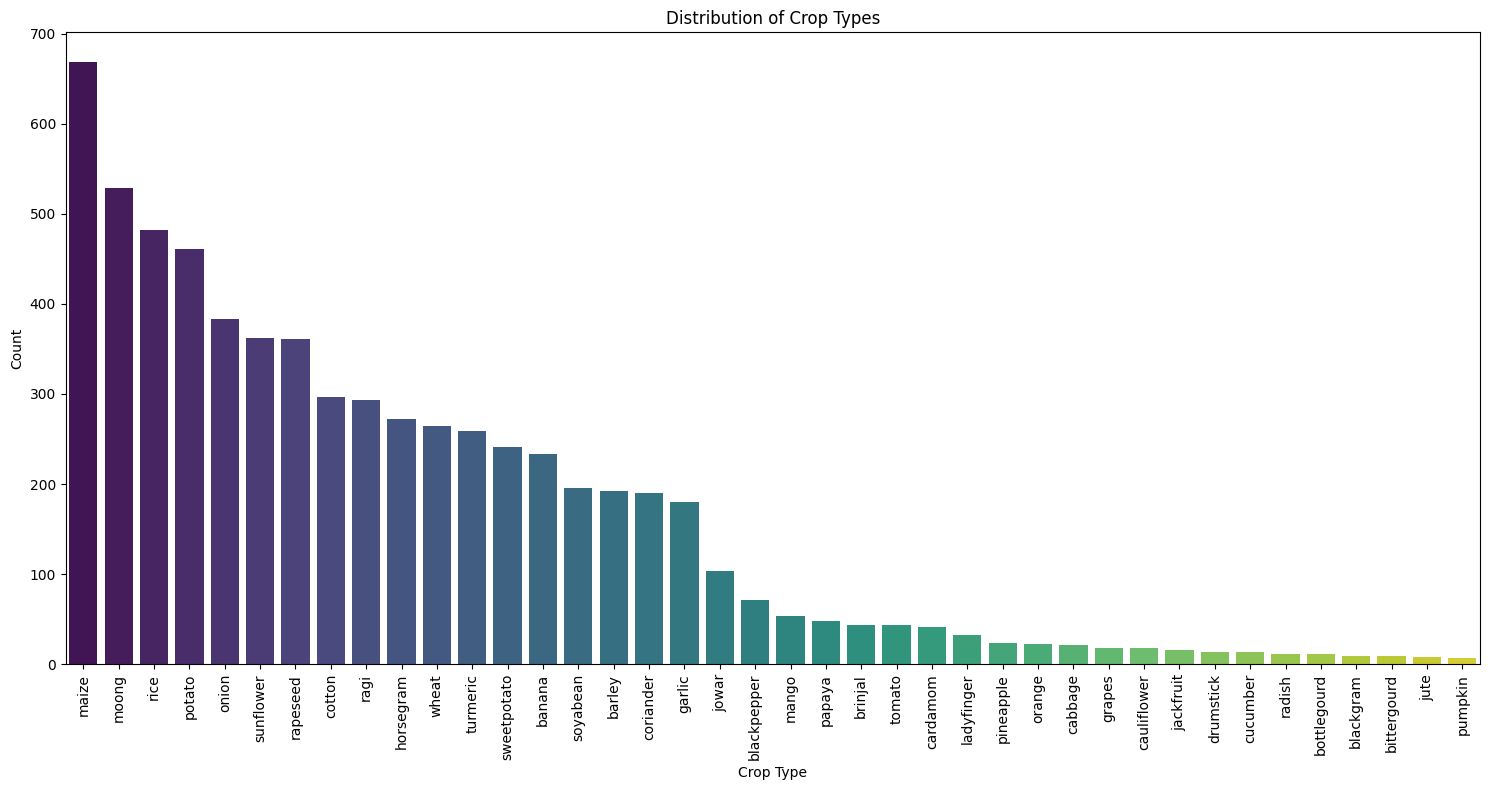

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts for the 'crop' column
crop_counts = df['crop'].value_counts()

# Create a bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x=crop_counts.index, y=crop_counts.values, hue=crop_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Crop Types')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 11. Feature Engineering

Create three ratio-based features that capture interactions between soil nutrients and climate:

| Feature | Formula | Agronomic meaning |
|---|---|---|
| `n_p_ratio` | N / (P + 1) | Nitrogen-to-Phosphorus balance |
| `n_k_ratio` | N / (K + 1) | Nitrogen-to-Potassium balance |
| `temp_rainfall` | temperature x rainfall | Heat-moisture interaction |

In [ ]:
df['n_p_ratio'] = df['n'] / (df['p'] + 1)
df['n_k_ratio'] = df['n'] / (df['k'] + 1)
df['temp_rainfall'] = df['temperature'] * df['rainfall']

## 12. Train / Test Split

In [ ]:
X = df.drop(columns=['crop'])
y = df['crop']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 13. Handle Class Imbalance with SMOTE

Synthetic Minority Over-sampling Technique (SMOTE) is applied **only to the training set** to create synthetic samples for minority crop classes without touching the test set.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

## 14. Combine Processed Training + Test Sets into Final Dataset

In [ ]:
# Combine X_train and X_test
X_combined = pd.concat([X_train, X_test], ignore_index=True)

# Combine y_train and y_test
y_combined = pd.concat([y_train, y_test], ignore_index=True)

# Convert y_combined to a DataFrame with a column name 'crop' to match X_combined for concatenation
y_combined_df = pd.DataFrame(y_combined, columns=['crop'])

# Combine the features and the target variable into a single DataFrame
combined_dataset = pd.concat([X_combined, y_combined_df], axis=1)

print("Shape of the combined dataset:", combined_dataset.shape)
print("First 5 rows of the combined dataset:")
display(combined_dataset.head())

Shape of the combined dataset: (22660, 10)
First 5 rows of the combined dataset:


,n,p,k,ph,rainfall,temperature,n_p_ratio,n_k_ratio,temp_rainfall,crop
0,25,60,100,4.82,2169.32,23.736364,0.409836,0.247525,51491.768372,turmeric
1,25,60,100,5.16,1299.26,26.518182,0.409836,0.247525,34454.012911,turmeric
2,50,40,20,5.02,87.20,23.106000,1.219512,2.380952,2014.843200,rapeseed
3,80,40,40,5.68,490.74,27.600000,1.951220,1.951220,13544.424000,rice
4,100,65,70,6.42,1111.68,28.648182,1.515152,1.408451,31847.610766,cabbage


In [ ]:
print(f"Shape of X_train after SMOTE: {X_train.shape}")
print(f"Shape of y_train after SMOTE: {y_train.shape}")

print("\nFirst 5 rows of X_train after SMOTE:")
display(X_train.head())

Shape of X_train after SMOTE: (21360, 9)
Shape of y_train after SMOTE: (21360,)

First 5 rows of X_train after SMOTE:


,n,p,k,ph,rainfall,temperature,n_p_ratio,n_k_ratio,temp_rainfall
0,25,60,100,4.82,2169.32,23.736364,0.409836,0.247525,51491.768372
1,25,60,100,5.16,1299.26,26.518182,0.409836,0.247525,34454.012911
2,50,40,20,5.02,87.20,23.106000,1.219512,2.380952,2014.843200
3,80,40,40,5.68,490.74,27.600000,1.951220,1.951220,13544.424000
4,100,65,70,6.42,1111.68,28.648182,1.515152,1.408451,31847.610766


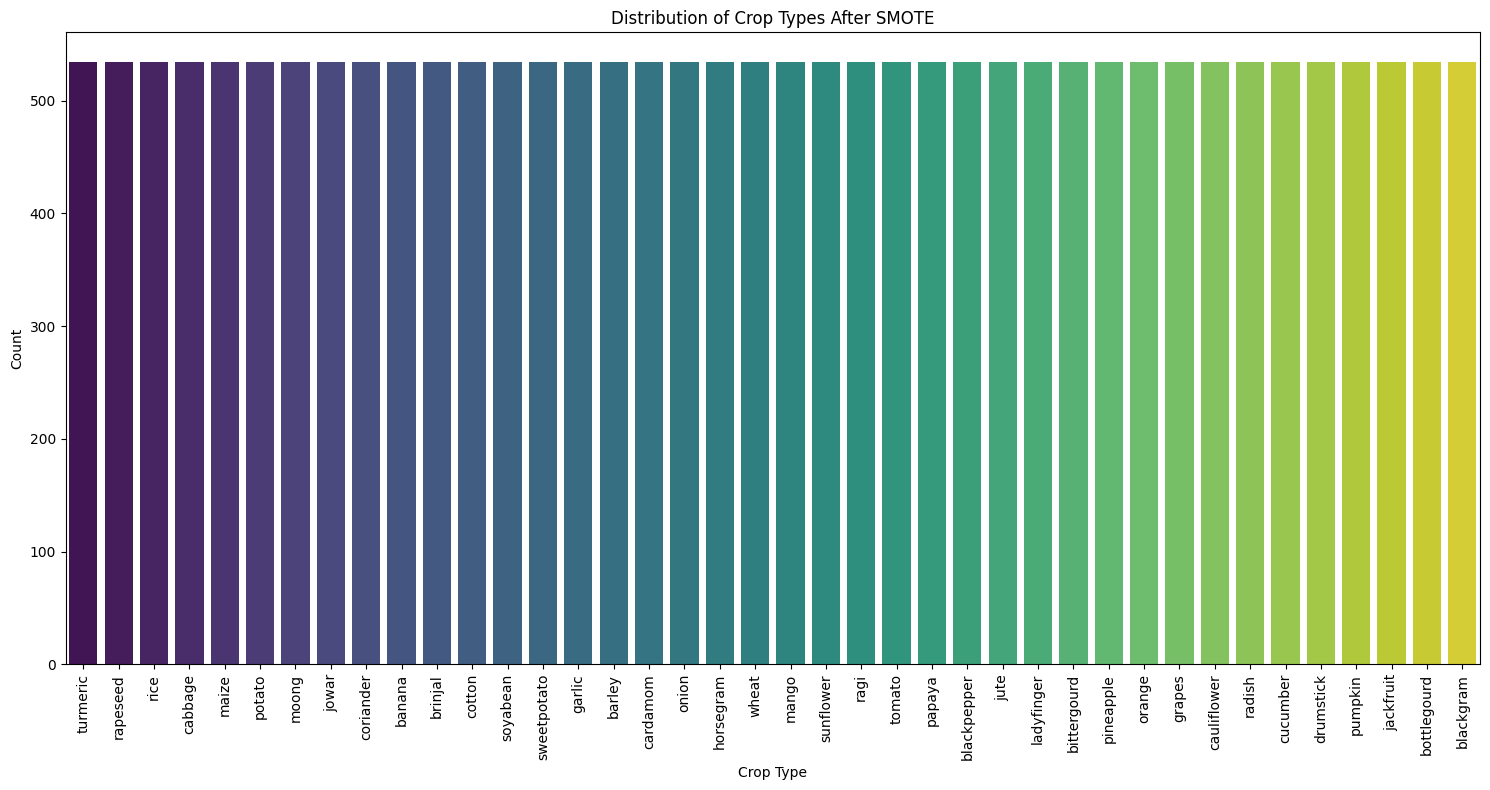

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts for the 'crop' column after SMOTE
smote_crop_counts = y_train.value_counts()

# Create a bar plot for SMOTE data
plt.figure(figsize=(15, 8))
sns.barplot(x=smote_crop_counts.index, y=smote_crop_counts.values, hue=smote_crop_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Crop Types After SMOTE')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 15. Sanity Check — Quick Random Forest Baseline

Train a lightweight Random Forest on the cleaned, SMOTE-resampled data to verify the pipeline is correct before saving.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split the SMOTE-resampled data into training and testing sets for RF
X_train_smote_rf, X_test_smote_rf, y_train_smote_rf, y_test_smote_rf = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Shape of X_train_smote_rf: {X_train_smote_rf.shape}")
print(f"Shape of y_train_smote_rf: {y_train_smote_rf.shape}")
print(f"Shape of X_test_smote_rf: {X_test_smote_rf.shape}")
print(f"Shape of y_test_smote_rf: {y_test_smote_rf.shape}")

Shape of X_train_smote_rf: (17088, 9)
Shape of y_train_smote_rf: (17088,)
Shape of X_test_smote_rf: (4272, 9)
Shape of y_test_smote_rf: (4272,)


In [ ]:
# Initialize and train the Random Forest Classifier on the SMOTE-resampled data
rf_model_smote = RandomForestClassifier(random_state=42)
rf_model_smote.fit(X_train_smote_rf, y_train_smote_rf)

# Make predictions on the test set from SMOTE-resampled data
y_pred_smote_rf = rf_model_smote.predict(X_test_smote_rf)

# Calculate and print the accuracy
accuracy_smote = accuracy_score(y_test_smote_rf, y_pred_smote_rf)
print(f"Random Forest Classifier Accuracy (after SMOTE): {accuracy_smote:.4f}")

Random Forest Classifier Accuracy (after SMOTE): 0.9967


In [ ]:
# Combine X_train (after SMOTE) and y_train (after SMOTE) into a single DataFrame
# Ensure y_train is converted to a DataFrame with a column name 'crop' for proper concatenation
y_train_df_smote = pd.DataFrame(y_train, columns=['crop'], index=X_train.index)
smote_dataset = pd.concat([X_train, y_train_df_smote], axis=1)

print(f"Shape of the SMOTE-resampled dataset: {smote_dataset.shape}")
print("First 5 rows of the SMOTE-resampled dataset:")
display(smote_dataset.head())

Shape of the SMOTE-resampled dataset: (21360, 10)
First 5 rows of the SMOTE-resampled dataset:


,n,p,k,ph,rainfall,temperature,n_p_ratio,n_k_ratio,temp_rainfall,crop
0,25,60,100,4.82,2169.32,23.736364,0.409836,0.247525,51491.768372,turmeric
1,25,60,100,5.16,1299.26,26.518182,0.409836,0.247525,34454.012911,turmeric
2,50,40,20,5.02,87.20,23.106000,1.219512,2.380952,2014.843200,rapeseed
3,80,40,40,5.68,490.74,27.600000,1.951220,1.951220,13544.424000,rice
4,100,65,70,6.42,1111.68,28.648182,1.515152,1.408451,31847.610766,cabbage


## 16. Save Processed Dataset

Save the final combined (SMOTE-resampled) dataset as `combined_dataset.csv`. This is the single input file consumed by `02_model_pipeline.ipynb`.

In [ ]:
# Save the processed dataset for use in the main modelling notebook
output_path = "../data/combined_dataset.csv"
smote_dataset.to_csv(output_path, index=False)
print("Saved combined_dataset.csv  shape:", smote_dataset.shape)
smote_dataset.head()